In [1]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import pandas as pd
import numpy as np

# 1. Cargar los polígonos que exportaste de QGIS (.geojson)
poligonos = gpd.read_file("poligonos_puerto.geojson")

# 2. Lista con las rutas de tus 10 bandas individuales descargadas
# 2. Lista con las rutas REALES de tus 10 bandas individuales descargadas
lista_bandas = [
    "2020-08-08-00_00_2020-08-08-23_59_Sentinel-2_L2A_B02_(Raw).tiff",  # B02 (Azul)
    "2020-08-08-00_00_2020-08-08-23_59_Sentinel-2_L2A_B03_(Raw).tiff",  # B03 (Verde)
    "2020-08-08-00_00_2020-08-08-23_59_Sentinel-2_L2A_B04_(Raw).tiff",  # B04 (Rojo)
    "2020-08-08-00_00_2020-08-08-23_59_Sentinel-2_L2A_B05_(Raw).tiff",  # B05 (Red Edge 1)
    "2020-08-08-00_00_2020-08-08-23_59_Sentinel-2_L2A_B06_(Raw).tiff",  # B06 (Red Edge 2)
    "2020-08-08-00_00_2020-08-08-23_59_Sentinel-2_L2A_B07_(Raw).tiff",  # B07 (Red Edge 3)
    "2020-08-08-00_00_2020-08-08-23_59_Sentinel-2_L2A_B08_(Raw).tiff",  # B08 (NIR)
    "2020-08-08-00_00_2020-08-08-23_59_Sentinel-2_L2A_B8A_(Raw).tiff",  # B8A (NIR Estrecho)
    "2020-08-08-00_00_2020-08-08-23_59_Sentinel-2_L2A_B11_(Raw).tiff",  # B11 (SWIR 1)
    "2020-08-08-00_00_2020-08-08-23_59_Sentinel-2_L2A_B12_(Raw).tiff"   # B12 (SWIR 2)
]
nombres_bandas = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]

datos_pixeles = []

# 3. Iterar polígono por polígono para extraer los píxeles
for idx, fila in poligonos.iterrows():
    clase_actual = fila['clase']  # Asegúrate de usar el nombre de tu columna ('clase' o 'class')
    geom = [fila['geometry']]
    
    # Diccionario temporal para guardar los datos espectrales de los píxeles de este polígono
    datos_poligono = {}
    coordenadas_guardadas = False
    filas_validas = None
    cols_validas = None
    
    for path, nombre_b in zip(lista_bandas, nombres_bandas):
        with rasterio.open(path) as src:
            # Recortar la banda usando el polígono actual sin forzar un valor nodata incompatible
            out_image, out_transform = mask(src, geom, crop=True, filled=False)
            banda_data = out_image[0]
            
            # Capturar los índices de los píxeles válidos usando la máscara real
            if filas_validas is None or cols_validas is None:
                filas_validas, cols_validas = np.where(~banda_data.mask)
            
            # Guardar los valores espectrales reflejados
            datos_poligono[nombre_b] = np.asarray(banda_data[filas_validas, cols_validas])
            
            # Extraer la Latitud y Longitud exacta de cada píxel (solo se hace en la primera banda)
            if not coordenadas_guardadas:
                lons, lats = rasterio.transform.xy(out_transform, filas_validas, cols_validas)
                datos_poligono['Latitude'] = lats
                datos_poligono['Longitude'] = lons
                coordenadas_guardadas = True
                
    # Convertir los datos de este polígono a un DataFrame temporal
    df_temporal = pd.DataFrame(datos_poligono)
    df_temporal['class'] = clase_actual
    datos_pixeles.append(df_temporal)

# 4. Consolidar todos los píxeles y exportar a TSV
dataset_final = pd.concat(datos_pixeles, ignore_index=True)
dataset_final.to_csv("training_dataset.tsv", sep="\t", index=False)
print(f"¡Dataset creado con éxito! Total de píxeles para entrenar: {len(dataset_final)}")

c:\Users\diego\OneDrive\Documentos\javeriana\tecnologias emergentes\geo_env\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 1 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


¡Dataset creado con éxito! Total de píxeles para entrenar: 7893


Cargando el archivo TSV...
Dataset cargado correctamente. Total de píxeles: 7893
Distribución por clase:
class
Agua          2163
Urbano        2056
Escombros     1546
Suelo         1512
Vegetacion     616
Name: count, dtype: int64

Entrenando el modelo inicial de Machine Learning...
¡Entrenamiento completado con éxito!

 OVERALL ACCURACY DEL MODELO INICIAL: 91.83%

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

        Agua       1.00      1.00      1.00       433
   Escombros       0.92      0.88      0.90       309
       Suelo       0.90      0.93      0.91       303
      Urbano       0.85      0.86      0.86       411
  Vegetacion       0.92      0.89      0.91       123

    accuracy                           0.92      1579
   macro avg       0.92      0.91      0.91      1579
weighted avg       0.92      0.92      0.92      1579



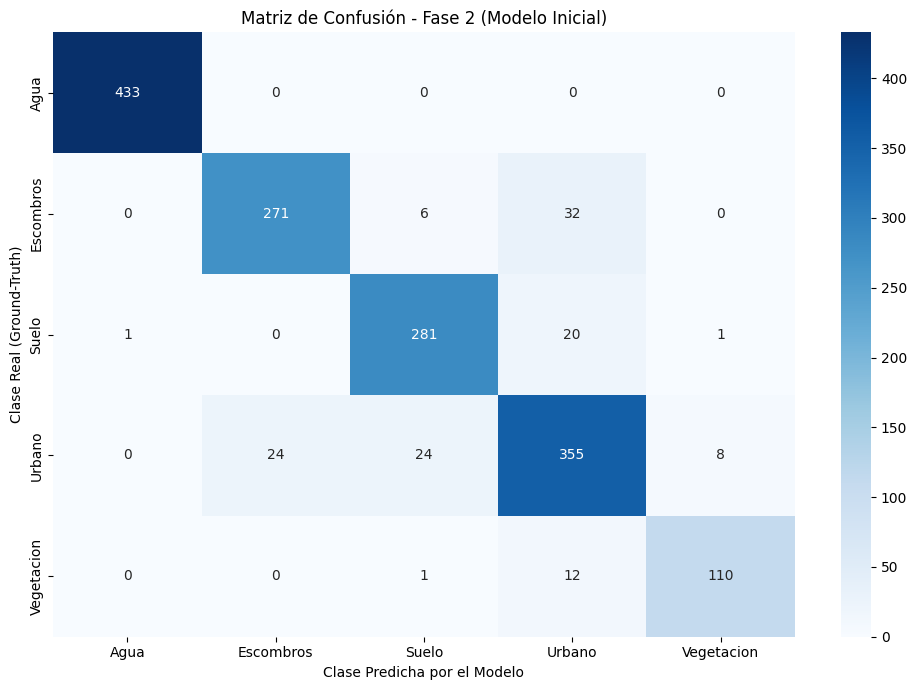

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar el dataset que acabamos de generar
print("Cargando el archivo TSV...")
df = pd.read_csv("training_dataset.tsv", sep="\t")
print(f"Dataset cargado correctamente. Total de píxeles: {len(df)}")
print(f"Distribución por clase:\n{df['class'].value_counts()}\n")

# 2. Separar características (X: solo las bandas espectrales) y etiquetas (y: las clases)
# Quitamos Latitude, Longitude y class de las X para entrenar solo con firmas espectrales
X = df.drop(columns=['Latitude', 'Longitude', 'class'])
y = df['class']

# 3. Dividir el dataset en entrenamiento (80%) y prueba (20%) de forma estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Escalar/Estandarizar los datos espectrales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Entrenar el clasificador inicial (Random Forest con 100 árboles)
print("Entrenando el modelo inicial de Machine Learning...")
modelo_inicial = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_inicial.fit(X_train_scaled, y_train)
print("¡Entrenamiento completado con éxito!\n")

# 6. Evaluar el rendimiento con los datos de prueba (20%)
y_pred = modelo_inicial.predict(X_test_scaled)

# Métrica 1: Overall Accuracy (Precisión Global)
accuracy = accuracy_score(y_test, y_pred)
print(f"==================================================")
print(f" OVERALL ACCURACY DEL MODELO INICIAL: {accuracy * 100:.2f}%")
print(f"==================================================\n")

# Reporte detallado por categoría
print("Reporte de Clasificación Detallado:")
print(classification_report(y_test, y_pred))

# Métrica 2: Matriz de Confusión (Gráfica)
clases_unicas = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred, labels=clases_unicas)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=clases_unicas, yticklabels=clases_unicas)
plt.title("Matriz de Confusión - Fase 2 (Modelo Inicial)")
plt.ylabel("Clase Real (Ground-Truth)")
plt.xlabel("Clase Predicha por el Modelo")
plt.tight_layout()
plt.show()